# AQI Forecasting — SARIMA Model
**Dataset:** Kodungaiyur_AQI_data.csv  
**Target:** Daily mean AQI  
**Model:** SARIMA(1,1,1)(1,1,1)[7] — captures weekly seasonality

SARIMA extends ARIMA with a seasonal component for periodic patterns.
This is a univariate model — only AQI values are used for forecasting.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('Libraries loaded successfully.')


Libraries loaded successfully.


## 1. Load & Preprocess Data


In [2]:
df = pd.read_csv('D:/AQI_Project/Data/Final/Kodungaiyur_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

# Interpolate missing values
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').interpolate(method='time')

# Daily aggregation — SARIMA uses AQI only (univariate)
daily = df.resample('D').mean().dropna(subset=['AQI'])

print(f'Daily records: {len(daily)}')
print(daily[['AQI']].head())


Daily records: 1826
                  AQI
Timestamp            
2021-01-01  48.865789
2021-01-02  85.609167
2021-01-03  74.642917
2021-01-04  62.708750
2021-01-05  50.482917


## 2. Seasonal Decomposition


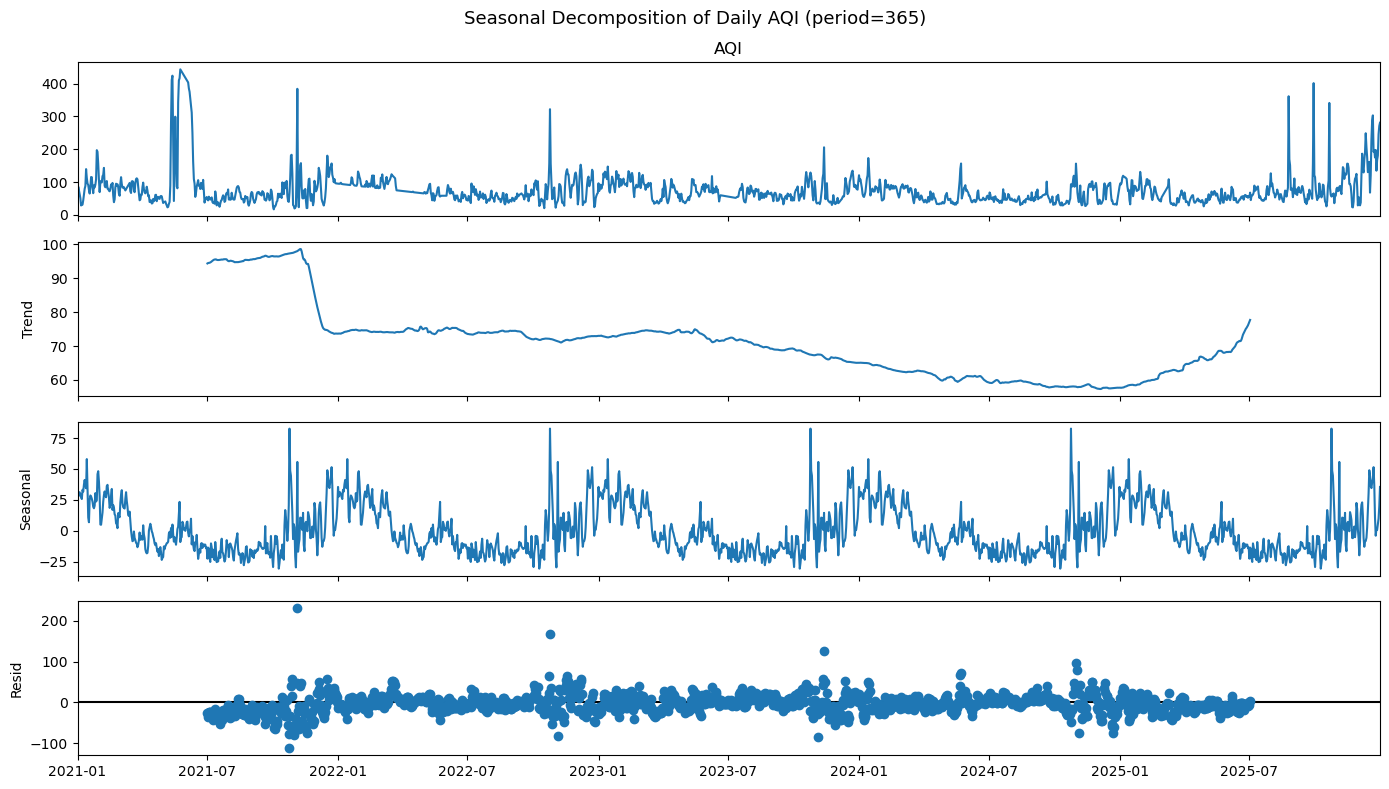

Weekly seasonal pattern clearly visible.


In [3]:
decomp = seasonal_decompose(daily['AQI'], model='additive', period=365)
fig = decomp.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Seasonal Decomposition of Daily AQI (period=365)', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/sarima_decomposition_kodungaiyur.png', dpi=150)
plt.show()
print('Weekly seasonal pattern clearly visible.')


## 3. Train/Test Split


In [4]:
# SARIMA is univariate — only the AQI series is needed
split_date = '2025-07-01'
train_y = daily['AQI'][:split_date]
test_y  = daily['AQI'][split_date:]

print(f'Train: {len(train_y)} | Test: {len(test_y)}')


Train: 1643 | Test: 184


## 4. Fit SARIMA(1,1,1)(1,1,1)[7]

Order: (p=1, d=1, q=1) non-seasonal  
Seasonal: (P=1, D=1, Q=1, s=7) weekly


In [5]:
def fourier_terms(index, period=365, K=3):
    import numpy as np
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K+1):
        cols[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

exog_train = fourier_terms(train_y.index)
exog_test  = fourier_terms(test_y.index)

model = SARIMAX(
    train_y,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit = model.fit(disp=False)
print(fit.summary())


                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1643
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -7496.955
Date:                Fri, 15 May 2026   AIC                          15011.911
Time:                        16:39:56   BIC                          15060.533
Sample:                    01-01-2021   HQIC                         15029.944
                         - 07-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         13.6276     10.880      1.253      0.210      -7.696      34.951
cos_1          8.2058      7.339      1.118      0.264      -6.179      22.591
sin_2         -5.6573      7.424     -0.762      0.4

## 5. Forecast & Evaluation


In [6]:
forecast = fit.forecast(steps=len(test_y), exog=exog_test)
forecast.index = test_y.index

rmse = np.sqrt(mean_squared_error(test_y, forecast))
mae  = mean_absolute_error(test_y, forecast)
mask = test_y.values != 0
mape = np.mean(np.abs((test_y.values[mask] - forecast.values[mask]) / test_y.values[mask])) * 100

print(f'SARIMA (Fourier) Performance:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')


SARIMA (Fourier) Performance:
  RMSE : 71.06
  MAE  : 42.50
  MAPE : 40.23%


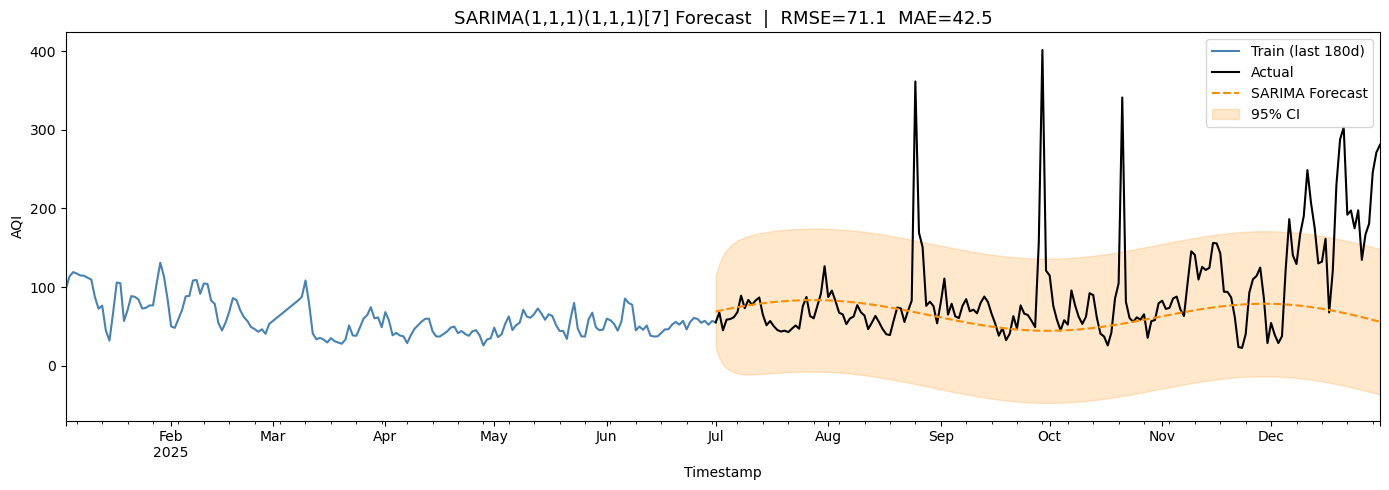

In [7]:
pred_obj = fit.get_forecast(steps=len(test_y), exog=exog_test)
ci = pred_obj.conf_int()
ci.index = test_y.index

fig, ax = plt.subplots(figsize=(14, 5))
train_y[-180:].plot(ax=ax, label='Train (last 180d)', color='steelblue')
test_y.plot(ax=ax, label='Actual', color='black', linewidth=1.5)
forecast.plot(ax=ax, label='SARIMA Forecast', color='darkorange', linestyle='--')
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color='darkorange', label='95% CI')
ax.set_title(f'SARIMA(1,1,1)(1,1,1)[7] Forecast  |  RMSE={rmse:.1f}  MAE={mae:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/sarima_forecast_kodungaiyur.png', dpi=150)
plt.show()


## 6. Residual Diagnostics


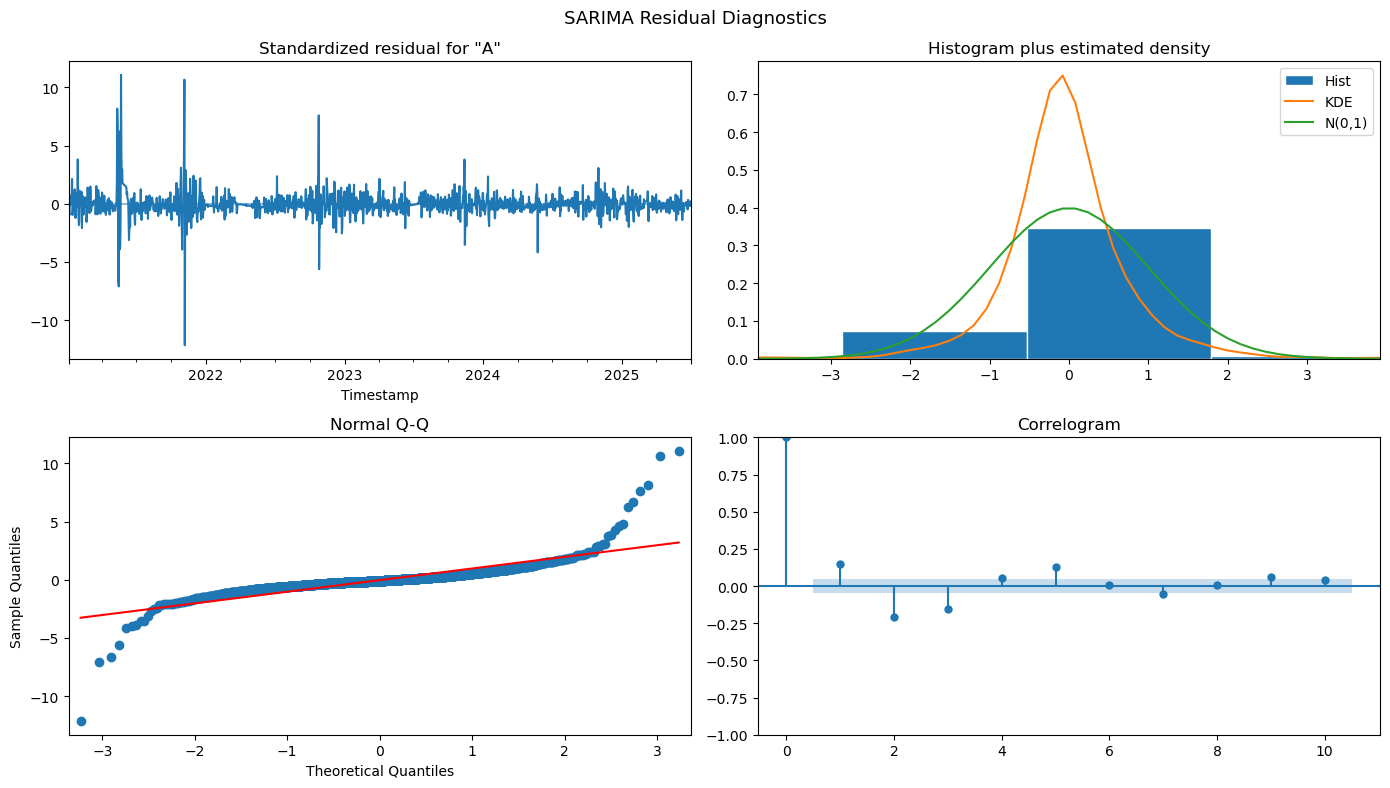

In [8]:
fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/sarima_diagnostics_kodungaiyur.png', dpi=150)
plt.show()


## 7. AIC/BIC Comparison (Model Selection)

If you want to try alternative orders:


In [9]:
print(f'Selected model AIC : {fit.aic:.2f}')
print(f'Selected model BIC : {fit.bic:.2f}')
print()
print('Lower AIC/BIC = better model fit vs complexity trade-off.')


Selected model AIC : 15011.91
Selected model BIC : 15060.53

Lower AIC/BIC = better model fit vs complexity trade-off.


## 8. Classification Metrics & Confusion Matrix
Converting continuous AQI forecasts into discrete AQI categories to evaluate classification performance (Accuracy, Precision, Recall).

Classification Metrics for AQI Categories:
Accuracy:  0.5109
Precision: 0.3619 (Weighted)
Recall:    0.5109 (Weighted)

Classification Report:
              precision    recall  f1-score   support

        Good       0.28      0.30      0.29        30
Satisfactory       0.56      0.82      0.66       104
    Moderate       0.00      0.00      0.00        39
        Poor       0.00      0.00      0.00         7
   Very Poor       0.00      0.00      0.00         3
      Severe       0.00      0.00      0.00         1

    accuracy                           0.51       184
   macro avg       0.14      0.19      0.16       184
weighted avg       0.36      0.51      0.42       184



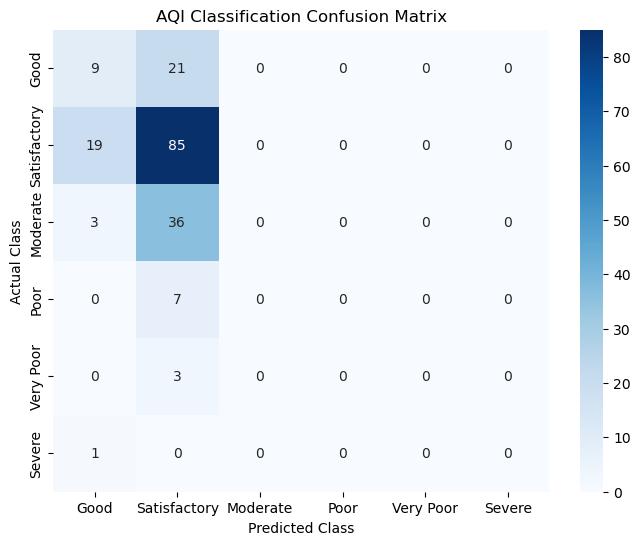

In [10]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Define AQI categories based on Indian standards
def categorize_aqi(aqi_values):
    categories = []
    for val in aqi_values:
        if val <= 50:
            categories.append('Good')
        elif val <= 100:
            categories.append('Satisfactory')
        elif val <= 200:
            categories.append('Moderate')
        elif val <= 300:
            categories.append('Poor')
        elif val <= 400:
            categories.append('Very Poor')
        else:
            categories.append('Severe')
    return np.array(categories)

# Ensure values are flattened arrays
y_true_cont = np.array(test_y.values).flatten()
y_pred_cont = np.array(forecast.values).flatten()

# Convert continuous predictions to discrete AQI classes
y_true_class = categorize_aqi(y_true_cont)
y_pred_class = categorize_aqi(y_pred_cont)

# Labels for standard Indian AQI
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
# Filter labels to only those present in the actual or predicted to avoid empty rows/cols if desired
# But keeping all labels shows a full matrix
present_labels = [l for l in labels if l in y_true_class or l in y_pred_class]

# Calculate Metrics
acc = accuracy_score(y_true_class, y_pred_class)
# weighted average for precision and recall since it's multiclass
prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
rec = recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0)

print(f"Classification Metrics for AQI Categories:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f} (Weighted)")
print(f"Recall:    {rec:.4f} (Weighted)\n")

print("Classification Report:")
print(classification_report(y_true_class, y_pred_class, labels=present_labels, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true_class, y_pred_class, labels=present_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=present_labels, yticklabels=present_labels)
plt.title('AQI Classification Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

os.makedirs('images', exist_ok=True)
plt.savefig('images/sarima_confusion_matrix_kodangaiyur.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
import pickle, os
os.makedirs('D:/AQI_Project/SARIMA/saved_models', exist_ok=True)
with open('D:/AQI_Project/SARIMA/saved_models/sarima_kodangaiyur.pkl', 'wb') as f:
    pickle.dump(fit, f)
print('Model saved as sarima_kodangaiyur.pkl')

Model saved as sarima_kodangaiyur.pkl
